# Imputación usando MissForest

In [10]:
# ################################################################################### #
# Script used for the imputation of the missing values of the dataset by means of the #
# technique MissForest. Reference:                                                    #
#                                                                                     #
#           Daniel J. Stekhoven and Peter Bühlmann. MissForest - nonparametric        #
#           missing value imputation for mixed-type data. 2011, 28, 1, 112-118.       #
#           DOI: 10.1093/bioinformatics/btr597.                                       #
#                                                                                     #
# ################################################################################### #    

## Idea general


1. Imputar numéricas + categóricas ordinales con “MissForest” (IterativeImputer + árboles)

2. Para categóricas nominales, NO imputarlas como números ni como one-hot continuo; imputarlas como categoría (más simple y estable).

Es necesario hacer esta separación porque:

- **Las ordinales sí tienen orden** → tiene sentido imputarlas como números y luego redondear

- **Las nominales no tienen orden** → imputarlas como números mete orden falso; imputarlas como one-hot con modelos de regresión deja dummies inconsistentes.

In [65]:
# Import basics
import pandas as pd
import numpy as np
import unicodedata
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import joblib
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

In [75]:
#USAR EL TRAIN RAW
df_train = pd.read_csv('data/trainset_raw.csv')
df_test = pd.read_csv('data/testset_raw.csv')

In [76]:
# Para asegurar que el imputador funcione bien convertimos los valores faltantes, representados en blanco, a NaN
df_train.replace("", np.nan, inplace=True)
df_test.replace("", np.nan, inplace=True)

In [77]:
print(df_train.shape)
print(df_test.shape)

(1964, 67)
(491, 67)


In [78]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1964 entries, 0 to 1963
Data columns (total 67 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   genero                          1964 non-null   int64  
 1   edad_an                         1964 non-null   float64
 2   raza_etnia                      1964 non-null   float64
 3   periodo_examen                  1964 non-null   int64  
 4   pais_nacimiento                 1964 non-null   int64  
 5   tamano_hogar                    1964 non-null   float64
 6   psu                             1964 non-null   float64
 7   ratio_pobreza                   1724 non-null   float64
 8   cant_suplementos                1554 non-null   float64
 9   cant_antiacidos                 1550 non-null   float64
 10  toma_suplementos                1964 non-null   int64  
 11  toma_antiacidos                 1964 non-null   int64  
 12  estado_examen_balance           19

In [79]:
pd.set_option('display.max_columns', None)
df_train.head()

,genero,edad_an,raza_etnia,periodo_examen,pais_nacimiento,tamano_hogar,psu,ratio_pobreza,cant_suplementos,cant_antiacidos,toma_suplementos,toma_antiacidos,estado_examen_balance,elegibilidad_balance,convulsiones,caidas,fracturas,medicacion_osteoporosis,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,aprueba_cond4,tiempo_seg_cond4,tamano_manguito_pa,peso_kg,altura_cm,imc,largo_pierna_superior_cm,largo_brazo_superior_cm,estado_elastografia,tipo_sonda_elasto,medidas_validas_elasto,intentos_totales_elasto,rigidez_mediana_kpa,rigidez_iqr,ratio_iqr_mediana,cap_mediana_db_m,cap_iqr,albumina_orina_mg_l,creatinina_orina_umol_l,ratio_albumina_creatinina,peso_flebotomia,leucocitos_totales,linfocitos_abs,monocitos_abs,neutrofilos_abs,eosinofilos_abs,basofilos_abs,eritrocitos_totales,hemoglobina_g_dl,volumen_corpuscular_medio,conc_hemoglobina_media,ancho_distribucion_eritrocitos,plaquetas_totales,volumen_plaquetario_medio,eritrocitos_nucleados,trigliceridos_mmol_l,ldl_martin_mmol_l,hdl_mmol_l,proteina_c_reactiva_mg_l,plomo_sangre_umol_l,cadmio_sangre_nmol_l,mercurio_sangre_nmol_l,selenio_sangre_umol_l,manganeso_sangre_nmol_l,hipertension,pulso
0,1,62.0,1.0,1,1,3.0,1.0,4.12,1.0,5.397605e-79,1,0,1,1,0,0,0,0,15.0,15.0,30.0,1,30.0,4.0,99.0,174.3,32.6,43.1,41.1,0,b'M',5.0,30.0,5.9,0.1,1.7,318.0,31.0,6.49,4862.0,11.80,13922.092915,4.6,1.6,0.5,2.3,0.1,1.000000e-01,4.61,15.0,95.0,34.2,13.2,223.0,7.3,5.397605e-79,0.824,1.991,1.06,0.70,0.041,1.157,60.98,2.75,170.92,0,53.0
1,0,67.0,3.0,0,1,7.0,2.0,0.87,4.0,5.397605e-79,1,0,1,1,0,0,0,0,15.0,15.0,30.0,0,6.0,4.0,90.7,156.5,37.0,34.8,37.5,1,b'XL',10.0,13.0,4.3,1.0,23.3,300.0,36.0,3.50,2917.2,10.61,21649.331276,5.7,1.2,0.6,3.6,0.2,5.397605e-79,4.23,12.9,95.1,32.2,13.8,226.0,8.4,5.397605e-79,1.818,2.664,1.11,12.66,0.019,4.155,0.60,1.92,118.86,1,61.0
2,1,51.0,4.0,0,1,2.0,1.0,0.19,NaN,NaN,1,0,0,1,0,0,0,0,15.0,15.0,30.0,0,3.0,4.0,120.3,184.0,35.5,45.5,40.3,1,b'XL',10.0,10.0,5.1,0.9,17.6,272.0,28.0,7.87,28111.2,2.47,83719.665280,5.9,1.7,0.6,3.5,0.1,5.397605e-79,4.69,13.7,90.0,32.5,13.3,271.0,8.4,1.000000e-01,0.768,2.198,1.42,6.51,0.066,2.331,1.20,2.25,149.80,0,66.0
3,0,51.0,3.0,0,1,1.0,1.0,1.25,NaN,NaN,1,0,1,0,0,0,1,0,15.0,15.0,22.0,0,18.0,3.0,50.6,159.4,19.9,35.6,35.5,1,b'M',10.0,10.0,4.8,0.3,6.3,185.0,25.0,5.35,4685.2,10.09,13180.056750,3.0,1.1,0.2,1.1,0.4,5.397605e-79,4.06,12.4,89.3,34.4,11.8,191.0,9.1,1.000000e-01,1.276,3.698,1.47,0.17,0.022,17.634,0.60,2.03,252.83,0,55.0
4,1,57.0,3.0,0,1,1.0,2.0,5.00,4.0,5.397605e-79,1,0,1,0,0,0,1,0,15.0,15.0,30.0,1,30.0,3.0,73.2,180.6,22.4,40.1,40.0,1,b'M',11.0,11.0,5.7,0.8,14.0,191.0,58.0,3.59,4066.4,7.80,53818.240080,4.2,1.1,0.5,2.5,0.1,5.397605e-79,4.73,15.5,92.0,35.6,13.1,257.0,8.0,1.000000e-01,0.892,3.155,1.68,0.41,0.032,2.651,1.15,2.72,213.69,0,76.0


In [80]:
df_train_target = df_train['hipertension']
df_train = df_train.drop(columns=['hipertension'])

df_test_target = df_test['hipertension']
df_test = df_test.drop(columns=['hipertension'])

In [81]:
print(df_test.shape)
print(df_train.shape)

(491, 66)
(1964, 66)


Cogemos las categóricas y las numéricas del excel

In [82]:
# 1. Cargar diccionario
ruta_diccionario = "data/Diccionario_TFM_Completo.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas_nominales = [col for col in cols_categoricas if col in df_train.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas = [col for col in cols_numericas if col in df_train.columns]


print(f"Número de columnas categóricas: {len(var_categoricas_nominales)}")
print(var_categoricas_nominales)

print(f"Número de columnas numéricas: {len(var_numericas)}")
print(var_numericas)

Número de columnas categóricas: 16
['genero', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 'medicacion_osteoporosis', 'aprueba_cond4', 'tamano_manguito_pa', 'estado_elastografia', 'tipo_sonda_elasto', 'raza_etnia']
Número de columnas numéricas: 49
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'cant_suplementos', 'cant_antiacidos', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'basofilos_a

In [83]:
import pandas as pd
import re

# =========================
# 1. Cargar Excel
# =========================
ruta_excel = "data/Diccionario_TFM_Completo.xlsx"
diccionario = pd.read_excel(ruta_excel)

# =========================
# 2. Función usada para limpiar nombres
# =========================
def limpiar_nombre(col):
    col = str(col).lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

# =========================
# 3. Valores de la columna "Qué es"
# =========================
valores_excel = diccionario["Qué es"].dropna().tolist()

print("=== VALORES DE 'Qué es' EN EL EXCEL ===")
for valor in valores_excel:
    print(valor)

# =========================
# 4. Nombres de columnas de df_train
# =========================
columnas_train = df_train.columns.tolist()

print("\n=== COLUMNAS DE df_train ===")
for col in columnas_train:
    print(col)

# =========================
# 5. Comparar usando formato limpio
# =========================
valores_excel_limpios = [limpiar_nombre(valor) for valor in valores_excel]

columnas_no_en_excel = [
    col for col in columnas_train
    if col not in valores_excel_limpios
]

# =========================
# 6. Resultado
# =========================
print("\n=== COLUMNAS DE df_train QUE NO APARECEN EN EL EXCEL ===")
print(f"Total: {len(columnas_no_en_excel)}")

for col in columnas_no_en_excel:
    print(col)

=== VALORES DE 'Qué es' EN EL EXCEL ===
ID
Ciclo
estado_entrevista
genero
edad_an
raza_etnia1
raza_etnia_3
periodo_examen
pais_nacimiento
tamano_hogar
peso_entrevista
peso_examen_mec
estrato
psu
ratio_pobreza
peso_dieta_dia1
cant_suplementos
cant_antiacidos
toma_suplementos
toma_antiacidos
estado_examen_balance
elegibilidad_balance
mareos
desmayos
convulsiones
dificultad_caminar
caidas
fracturas
test_densidad_osea
medicacion_osteoporosis
diagnostico_osteoporosis
aprueba_cond1
tiempo_seg_cond1
aprueba_cond2
tiempo_seg_cond2
aprueba_cond3
tiempo_seg_cond3
aprueba_cond4
tiempo_seg_cond4
brazo_medicion_pa
tamano_manguito_pa
pa_sistolica_1
pa_diastolica_1
pa_sistolica_2
pa_diastolica_2
pa_sistolica_3
pa_diastolica_3
pulso_1
pulso_2
pulso_3
estado_medidas_corp
peso_kg
altura_cm
imc
largo_pierna_superior_cm
largo_brazo_superior_cm
circunferencia_brazo_cm
circunferencia_cintura_cm
circunferencia_cadera_cm
estado_elastografia
tipo_sonda_elasto
medidas_validas_elasto
intentos_totales_elasto
rigi

In [ ]:
# # 1. Variables Numéricas (Continuas y Discretas)
# # Total: 51 variables
# var_numericas = [
#     'edad_an', 'ratio_pobreza', 'cant_suplementos'  
#     'tiempo_seg_cond1', 'tiempo_seg_cond2', 
#     'tiempo_seg_cond3', 'tiempo_seg_cond4', 'peso_kg', 'altura_cm', 'imc', 
#     'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 
#     'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 
#     'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 
#     'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 
#     'peso_flebotomia', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 
#     'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 
#     'hemoglobina_g_dl', 'volumen_corpuscular_medio', 'conc_hemoglobina_media', 
#     'ancho_distribucion_eritrocitos', 'plaquetas_totales', 
#     'volumen_plaquetario_medio', 
#     'trigliceridos_mmol_l', 'ldl_martin_mmol_l', 'hdl_mmol_l', 
#     'proteina_c_reactiva_mg_l', 'plomo_sangre_umol_l', 'cadmio_sangre_nmol_l', 
#     'mercurio_sangre_nmol_l', 'selenio_sangre_umol_l', 'manganeso_sangre_nmol_l', 
#     'pulso'
# ]

# # 2. Variables Categóricas Nominales (Sin orden intrínseco, incluye variables de diseño como psu y estrato)
# # Total: 18 variables
# var_categoricas_nominales = [
#     'genero', 'raza_etnia', 'periodo_examen', 'pais_nacimiento', 'psu', 
#     'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 
#     'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 
#     'medicacion_osteoporosis', 'aprueba_cond4', 'estado_elastografia', 
#     'tipo_sonda_elasto'
# ]

# # 3. Variables Categóricas Ordinales (Con jerarquía/orden intrínseco)
# # Total: 2 variables
# var_categoricas_ordinales = [
#     'tamano_manguito_pa', 
#     'tamano_hogar' # Numérica discreta truncada (7 = "7 o más"), se trata como ordinal
# ]

# # Comprobación de que están todas las columnas
# print(f"Total variables numéricas: {len(var_numericas)}")
# print(f"Total variables nominales: {len(var_categoricas_nominales)}")
# print(f"Total variables ordinales: {len(var_categoricas_ordinales)}")
# print(f"Total general: {len(var_numericas) + len(var_categoricas_nominales) + len(var_categoricas_ordinales)}")

Total variables numéricas: 44
Total variables nominales: 16
Total variables ordinales: 2
Total general: 62


In [ ]:
train_numerica = df_train[var_numericas]
#train_ord = df_train[var_categoricas_ordinales]
train_nom = df_train[var_categoricas_nominales]

test_numerica = df_test[var_numericas]
#test_ord = df_test[var_categoricas_ordinales]
test_nom = df_test[var_categoricas_nominales]

### Esta es la celda que usaríamos si antes hiciesemos split en train/test

In [10]:
# Funciones para la imputación
def _missForest_fit(data, num_estimators, m_depth, m_samples_leaf, max_iter,
                    min_value=None, max_value=None, random_state=1234):
    tree = ExtraTreesRegressor(n_estimators=num_estimators,
                               random_state=random_state,
                               max_depth=m_depth,
                               min_samples_leaf=m_samples_leaf)
    imputer = IterativeImputer(estimator=tree,
                               random_state=random_state,
                               max_iter=max_iter,
                               min_value=min_value,
                               max_value=max_value,
                               imputation_order='ascending',
                               initial_strategy='mean',
                               verbose=2)
    imputer.fit(data)
    return imputer

def _missForest_transform(imputer, data):
    return imputer.transform(data)


def imputacion_pipeline(train_num, test_num,num_estimators, 
                        m_depth, m_samples_leaf,
                        max_iter, random_state=1234,
                        guardar_imputador=True):

    # Obtener min/max automáticamente por nombre de variable
    min_values_num = [min_values_dict[col] for col in train_num.columns]
    max_values_num = [max_values_dict[col] for col in train_num.columns]

    min_values_all = [min_values_dict[col] for col in list(train_num.columns)]
    max_values_all = [max_values_dict[col] for col in list(train_num.columns)]

    
    # Imputación de numéricas
    imputer_num = _missForest_fit(train_num, num_estimators, m_depth, m_samples_leaf,
                                  max_iter, min_value=min_values_num,
                                  max_value=max_values_num,
                                  random_state=random_state)
    train_num_imp = pd.DataFrame(_missForest_transform(imputer_num, train_num),
                                 columns=train_num.columns,
                                 index=train_num.index)
    test_num_imp = pd.DataFrame(_missForest_transform(imputer_num, test_num),
                                columns=test_num.columns,
                                index=test_num.index)

    # Unir con categóricas
    train_all = pd.concat([train_num_imp], axis=1)
    test_all = pd.concat([test_num_imp], axis=1)

    # Imputación conjunta
    imputer_all = _missForest_fit(train_all, num_estimators, m_depth, m_samples_leaf,
                                  max_iter, min_value=min_values_all,
                                  max_value=max_values_all,
                                  random_state=random_state)
    train_all_imp = _missForest_transform(imputer_all, train_all)
    test_all_imp = _missForest_transform(imputer_all, test_all)

    # Control de variables categóricas
    for i in range(train_num.shape[1], train_all.shape[1]):
        train_all_imp[:, i] = np.clip(train_all_imp[:, i], min_values_all[i], max_values_all[i])
        test_all_imp[:, i] = np.clip(test_all_imp[:, i], min_values_all[i], max_values_all[i])

    train_final = pd.DataFrame(train_all_imp, columns=train_all.columns, index=train_all.index)
    test_final = pd.DataFrame(test_all_imp, columns=test_all.columns, index=test_all.index)

    if guardar_imputador:
        joblib.dump(imputer_all, 'imputador_missforest.pkl')
        print("Imputador guardado como 'imputador_missforest.pkl'")

    return train_final, test_final

## Flujo general del código

**1. Definición de rangos permitidos (min_value y max_value)**

El imputador MissForest, a través de IterativeImputer, puede imputar valores fuera de los rangos clínicos reales si no se le ponen restricciones.  Por ello, se definen dos diccionarios: min_values_dict (mapeo de cada variable a su valor mínimo aceptado) y max_values_dict (mapeo de cada variable, su valor máximo aceptado). Esto se hace por nombre de variable para evitar errores si se cambia el orden de las columnas.

**2. Entrenamiento del imputador MissForest solo en datos de entrenamiento**

Este paso es necesario para evitar data leakage, el imputador se entrena solo con datos de entrenamiento. Luego se aplica al conjunto de test sin volver a ajustar.

**3. Aplicación del imputador a test**

El conjunto de test debe representar datos nunca vistos. Solo podemos usar el imputador previamente entrenado en train, ya que en producción no conoceremos la distribución real del test.

**4. Unión de variables categóricas (no imputadas todavía)**

Las categóricas también deben imputarse si tienen valores faltantes. Por eficiencia y consistencia, se hace una segunda imputación sobre todo el conjunto combinado (números ya imputados + categóricas originales).

**5. Imputación conjunta de numéricas + categóricas**

Esta segunda imputación considera interacciones entre variables numéricas y categóricas. Se usan min_values_all y max_values_all que incluyen las restricciones de todas las variables.

**6. Clipping y redondeo de variables categóricas**

Aunque se hayan definido rangos, MissForest puede producir pequeños decimales. Las variables categóricas deben ser redondeadas al entero más cercano y convertidas a int.

**7. Guardado del imputador para producción**

Guardar el imputador permite reutilizarlo en producción (por ejemplo, en una API Flask), garantizando que los datos futuros se traten exactamente igual que los del entrenamiento.

### Esta es la celda que utilizamos sin dividir en train/test 

In [11]:
# # Funciones para la imputación
# def _missForest_fit(data, num_estimators, m_depth, m_samples_leaf, max_iter,
#                     min_value=None, max_value=None, random_state=1234):
#     tree = ExtraTreesRegressor(
#         n_estimators=num_estimators,
#         random_state=random_state,
#         max_depth=m_depth,
#         min_samples_leaf=m_samples_leaf
#     )
#     imputer = IterativeImputer(
#         estimator=tree,
#         random_state=random_state,
#         max_iter=max_iter,
#         min_value=min_value,
#         max_value=max_value,
#         imputation_order='ascending',
#         initial_strategy='mean',
#         verbose=2
#     )
#     imputer.fit(data)
#     return imputer

# def _missForest_transform(imputer, data):
#     return imputer.transform(data)


# def imputacion_pipeline_all(data_num, num_estimators, 
#                             m_depth, m_samples_leaf,
#                             max_iter, random_state=1234,
#                             guardar_imputador=True):

#     # Obtener min/max automáticamente por nombre de variable
#     min_values_num = [min_values_dict[col] for col in data_num.columns]
#     max_values_num = [max_values_dict[col] for col in data_num.columns]

#     min_values_all = [min_values_dict[col] for col in list(data_num.columns)]
#     max_values_all = [max_values_dict[col] for col in list(data_num.columns)]

#     # Imputación de numéricas
#     imputer_num = _missForest_fit(
#         data_num, num_estimators, m_depth, m_samples_leaf,
#         max_iter, min_value=min_values_num,
#         max_value=max_values_num,
#         random_state=random_state
#     )

#     data_num_imp = pd.DataFrame(
#         _missForest_transform(imputer_num, data_num),
#         columns=data_num.columns,
#         index=data_num.index
#     )

#     # Unir con categóricas (ordinales)
#     data_all = pd.concat([data_num_imp], axis=1)

#     # Imputación conjunta
#     imputer_all = _missForest_fit(
#         data_all, num_estimators, m_depth, m_samples_leaf,
#         max_iter, min_value=min_values_all,
#         max_value=max_values_all,
#         random_state=random_state
#     )

#     data_all_imp = _missForest_transform(imputer_all, data_all)

#     # Control de variables categóricas (ordinales)
#     for i in range(data_num.shape[1], data_all.shape[1]):
#         data_all_imp[:, i] = np.clip(data_all_imp[:, i], min_values_all[i], max_values_all[i])

#     data_final = pd.DataFrame(data_all_imp, columns=data_all.columns, index=data_all.index)

#     if guardar_imputador:
#         joblib.dump(imputer_all, 'imputador_missforest.pkl')
#         print("Imputador guardado como 'imputador_missforest.pkl'")

#     return data_final

## Los rangos min_value y max_value deben calcularse exclusivamente sobre el conjunto de train

Así evitamos **data leakage**. Si extraemos los valores mínimos y máximos de todo el dataset, estarías indirectamente "mirando" los datos de test durante el entrenamiento del imputador → esto contamina el modelo.

**Coherencia con la imputación**: MissForest usa los rangos para limitar las predicciones durante el proceso iterativo. Si esos rangos provienen de test, estás condicionando la forma en la que el modelo "aprende" los valores del train.

**Producción realista**: En un entorno real, nunca dispones del test en el momento de entrenar el modelo. Así que los rangos utilizados deben derivarse únicamente de los datos conocidos (train).

**¿Qué pasa si en test hay valores fuera de los rangos de train?**

Esto no debería ocurrir si: hemos realizado una buena división estratificada y la muestra de train es representativa.

Pero si ocurre, no debemos ajustar los rangos. En su lugar, podemos:

- Aplicar un clip() posterior para limitar valores extremos en test.

- Analizar si el test contiene poblaciones diferentes y considerar un rediseño del muestreo.

In [ ]:
# Calculamos los diccionarios de mínimos y máximos EXCLUSIVAMENTE con el Train
# Unimos numéricas y ordinales temporalmente solo para extraer sus límites
train_num = train_numerica
test_num = test_numerica
min_values_dict = train_num.min().to_dict()
max_values_dict = train_num.max().to_dict()

# Convertimos a Series para usar la función clip()
series_min = pd.Series(min_values_dict)
series_max = pd.Series(max_values_dict)

# Recortamos el conjunto de Test ANTES de la imputación
test_num = test_num.clip(lower=series_min, upper=series_max, axis=1)


In [13]:
# ==========================================
# COMPROBACIÓN DE VALORES RECORTADOS (CLIPPING)
# ==========================================
# 1. Hacemos la copia ANTES de recortar
test_num_original = test_num.copy()

# 2. Aplicamos el recorte 
test_num = test_num.clip(lower=series_min, upper=series_max, axis=1)

# 3. Función para comparar (igual a la tuya)
def reporte_clipping(df_original, df_recortado, nombre_dataset):
    diferencias = (df_original != df_recortado) & df_original.notna()
    conteos = diferencias.sum()
    columnas_modificadas = conteos[conteos > 0]
    
    print(f"\n--- Reporte de Clipping: {nombre_dataset} ---")
    if columnas_modificadas.empty:
        print("No se recortó ningún valor. Todos estaban dentro de los límites del Train.")
    else:
        print(f"Se recortaron valores en {len(columnas_modificadas)} variables:")
        for col, cantidad in columnas_modificadas.items():
            print(f" - {col}: {cantidad} valores modificados")

# 4. Mostrar el reporte
reporte_clipping(test_num_original, test_num, "Variables Numéricas y Ordinales")


--- Reporte de Clipping: Variables Numéricas y Ordinales ---
No se recortó ningún valor. Todos estaban dentro de los límites del Train.


In [14]:
min_values_dict

{'edad_an': 20.0,
 'ratio_pobreza': 5.397605346934028e-79,
 'tiempo_seg_cond1': 1.0,
 'tiempo_seg_cond2': 5.397605346934028e-79,
 'tiempo_seg_cond3': 1.0,
 'tiempo_seg_cond4': 5.397605346934028e-79,
 'peso_kg': 27.9,
 'altura_cm': 133.0,
 'imc': 11.1,
 'largo_pierna_superior_cm': 24.9,
 'largo_brazo_superior_cm': 29.1,
 'medidas_validas_elasto': 5.397605346934028e-79,
 'intentos_totales_elasto': 5.397605346934028e-79,
 'rigidez_mediana_kpa': 1.7,
 'rigidez_iqr': 5.397605346934028e-79,
 'ratio_iqr_mediana': 5.397605346934028e-79,
 'cap_mediana_db_m': 100.0,
 'cap_iqr': 5.397605346934028e-79,
 'albumina_orina_mg_l': 0.21,
 'creatinina_orina_umol_l': 618.8,
 'ratio_albumina_creatinina': 0.3,
 'peso_flebotomia': 6625.125773451043,
 'leucocitos_totales': 2.2,
 'linfocitos_abs': 0.4,
 'monocitos_abs': 0.2,
 'neutrofilos_abs': 0.6,
 'eosinofilos_abs': 5.397605346934028e-79,
 'eritrocitos_totales': 2.74,
 'hemoglobina_g_dl': 6.6,
 'volumen_corpuscular_medio': 52.5,
 'conc_hemoglobina_media': 2

In [15]:
max_values_dict

{'edad_an': 69.0,
 'ratio_pobreza': 5.0,
 'tiempo_seg_cond1': 15.0,
 'tiempo_seg_cond2': 15.0,
 'tiempo_seg_cond3': 30.0,
 'tiempo_seg_cond4': 30.0,
 'peso_kg': 191.5,
 'altura_cm': 198.1,
 'imc': 67.8,
 'largo_pierna_superior_cm': 49.8,
 'largo_brazo_superior_cm': 49.2,
 'medidas_validas_elasto': 30.0,
 'intentos_totales_elasto': 30.0,
 'rigidez_mediana_kpa': 75.0,
 'rigidez_iqr': 53.3,
 'ratio_iqr_mediana': 127.7,
 'cap_mediana_db_m': 400.0,
 'cap_iqr': 207.0,
 'albumina_orina_mg_l': 3325.46,
 'creatinina_orina_umol_l': 71162.0,
 'ratio_albumina_creatinina': 5763.61,
 'peso_flebotomia': 227206.3685268616,
 'leucocitos_totales': 18.4,
 'linfocitos_abs': 6.1,
 'monocitos_abs': 1.7,
 'neutrofilos_abs': 14.6,
 'eosinofilos_abs': 1.5,
 'eritrocitos_totales': 7.08,
 'hemoglobina_g_dl': 18.6,
 'volumen_corpuscular_medio': 113.3,
 'conc_hemoglobina_media': 37.7,
 'ancho_distribucion_eritrocitos': 37.5,
 'plaquetas_totales': 576.0,
 'volumen_plaquetario_medio': 12.5,
 'trigliceridos_mmol_l': 

## ¿Por qué se realiza la imputación en 2 pasos: primero variables numéricas y luego numéricas+categóricas?

Imputamos primero solo las variables numéricas por:

1. Mejor estabilidad del imputador numérico

Los algoritmos como MissForest (basado aquí en IterativeImputer + ExtraTreesRegressor) pueden beneficiarse de entrenarse primero solo con variables numéricas. Esto:

- Reduce el ruido introducido por las categóricas codificadas como números

- Mejora la estimación de patrones numéricos y relaciones entre variables continuas.

- Permite detectar y excluir variables problemáticas antes de mezclar tipos de datos (por ejemplo, variables constantes o con distribución extraña).

2. Control independiente de los rangos

A nivel práctico, se puede definir una lista más sencilla de min_values y max_values solo para variables numéricas y verificar su comportamiento antes de introducir restricciones adicionales para categóricas.

**¿Por qué luego se imputan conjuntamente las numéricas (ya imputadas) y las categóricas?**

Una vez imputadas las numéricas, se hace una segunda imputación conjunta de: numéricas_imputadas + categóricas_con_missing


1. Mejora de la imputación de categóricas

Las variables categóricas se imputan mejor si se aprovecha la información de las variables numéricas completas. Por ejemplo:

La paridad puede estar relacionada con la edad materna o con el IMC.

La codificación de Doppler puede depender del flujo sanguíneo cuantificado en variables continuas.

2. Coherencia entre variables

Permite capturar dependencias cruzadas entre tipos de variables (ej. una categoría que suele coincidir con valores altos en una variable continua).

3. No se reimputan las numéricas

En esta segunda etapa, las numéricas ya imputadas no se modifican, pero participan como predictores para imputar las categóricas. (El IterativeImputer respeta valores ya imputados si se le pasan como entrada sin NaNs).

Los rangos tienen que estar ordenados en función de lo que "entre" a la imputación.

1. Imputación de las variables numéricas (train_num): rangos min/max en este orden

2. Imputación de las variables numéricas + categóricas: aquí lo que "entra" a la imputación es train_all = pd.concat([train_num, train_cat], axis=1). Por lo tanto, el orden correcto de los rangos min/max será primero todas las numéricas y luego todas las categóricas. 

In [16]:
#min_values_all = [min_values_dict[col] for col in list(df_num.columns) + list(df_cat_ord.columns)]
#max_values_all = [max_values_dict[col] for col in list(df_num.columns) + list(df_cat_ord.columns)]
#max_values_all

### Importante 

Aunque MissForest solo modifica las variables con valores faltantes, el imputador necesita todas las columnas para predecir, por eso hay que establecer correctamente los rangos min_value y max_value para todas las columnas, incluso las que no tienen valores faltantes, para evitar imputaciones fuera de rango cuando esas columnas sirven como predictores.

### Función cuando hacemos split en train/test

In [17]:
# train_num, test_num = train_test_split(
#     df_num,
#     test_size=0.2,
#     random_state=1234
# )

In [18]:
# Llamar a la función para imputar
train_final, test_final = imputacion_pipeline(
    train_num=train_num,
    test_num=test_num,
    #train_cat=train_cat,
    #test_cat=test_cat,
    num_estimators=50, # Número de árboles en el modelo ExtraTrees
    m_depth=4, # Profundidad máxima de los árboles
    m_samples_leaf=3, # Mínimo de muestras en cada hoja
    max_iter=100,
    random_state=1234,
    guardar_imputador=True
)

[IterativeImputer] Completing matrix with shape (1965, 46)
[IterativeImputer] Ending imputation round 1/100, elapsed time 5.02
[IterativeImputer] Change: 3587.3484963868827, scaled tolerance: 227.2063685268616 
[IterativeImputer] Ending imputation round 2/100, elapsed time 9.51
[IterativeImputer] Change: 869.7691303079622, scaled tolerance: 227.2063685268616 
[IterativeImputer] Ending imputation round 3/100, elapsed time 13.28
[IterativeImputer] Change: 622.1231693457327, scaled tolerance: 227.2063685268616 
[IterativeImputer] Ending imputation round 4/100, elapsed time 16.99
[IterativeImputer] Change: 221.2257034073485, scaled tolerance: 227.2063685268616 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (1965, 46)
[IterativeImputer] Ending imputation round 1/4, elapsed time 0.10
[IterativeImputer] Ending imputation round 2/4, elapsed time 0.21
[IterativeImputer] Ending imputation round 3/4, elapsed time 0.32
[IterativeImputer] Endin

Redondeo de las variables categoricas ordinales

In [ ]:
# for col in var_categoricas_ordinales:
#     train_final[col] = np.round(train_final[col])
#     test_final[col] = np.round(test_final[col])

### Función sin split en train/test

In [20]:
# data_final = imputacion_pipeline_all(
#     data_num=df_num,
#     #data_cat=df_cat_ord,   # aquí SOLO ordinales (codificadas como enteros)
#     num_estimators=50,
#     m_depth=4,
#     m_samples_leaf=3,
#     max_iter=100,
#     random_state=1234,
#     guardar_imputador=True)

### Imputación de las variables categóricas nominales usando la moda

In [21]:
def impute_nominal_simple(X_nom):
    imp = SimpleImputer(strategy='most_frequent')
    X_nom_imp = pd.DataFrame(imp.fit_transform(X_nom), columns=X_nom.columns, index=X_nom.index)
    return X_nom_imp, imp

In [22]:
train_nom_imp, imp_nom = impute_nominal_simple(train_nom)

In [23]:
# 3. Aplicamos la imputación al TEST (Sin usar la función, para evitar Leakage)
# Usamos el 'imp_nom' que aprendió del Train y solo hacemos .transform()
test_nom_imp = pd.DataFrame(
    imp_nom.transform(test_nom), 
    columns=test_nom.columns, 
    index=test_nom.index
)

### Unión de todas las variables

In [24]:
df_train_completo = pd.concat([train_final, train_nom_imp], axis=1)
df_test_completo = pd.concat([test_final, test_nom_imp], axis=1)

In [25]:
# Comprobar que no hay valores faltantes
print(f"Valores nulos en Train final: {df_train_completo.isna().sum().sum()}")
print(f"Valores nulos en Test final:  {df_test_completo.isna().sum().sum()}")

Valores nulos en Train final: 0
Valores nulos en Test final:  0


## Comparación de la distribución

En esta parte lo que comparamos es:

- **Distribución original**: los valores no nulos originales 

- **Distribución imputada completa**: todos los valores del train tras imputar, que incluyen imputados + originales.

Así podemos responder preguntas como: **¿La imputación ha distorsionado de forma visible la forma de la distribución?**

In [ ]:
# =====================================================================
# 1. COMPARACIÓN DE LÍMITES (MÍNIMOS Y MÁXIMOS)
# =====================================================================
print("Analizando los límites de las variables numéricas y ordinales...\n")

# Creamos un DataFrame para comparar los límites
df_limites = pd.DataFrame({
    'Min_Original': df_train[var_numericas + var_categoricas_ordinales].min(),
    'Min_Imputado': df_train_completo[var_numericas + var_categoricas_ordinales].min(),
    'Max_Original': df_train[var_numericas + var_categoricas_ordinales].max(),
    'Max_Imputado': df_train_completo[var_numericas + var_categoricas_ordinales].max()
})

# Calculamos si hay alguna diferencia (debería ser 0 o muy cercana a 0 por los decimales)
df_limites['Diff_Min'] = df_limites['Min_Imputado'] - df_limites['Min_Original']
df_limites['Diff_Max'] = df_limites['Max_Imputado'] - df_limites['Max_Original']

# Mostramos un resumen de las variables donde la diferencia sea mayor a un pequeño margen (por redondeos)
diferencias_reales = df_limites[(abs(df_limites['Diff_Min']) > 0.01) | (abs(df_limites['Diff_Max']) > 0.01)]

if diferencias_reales.empty:
    print("Todos los mínimos y máximos se han mantenido intactos tras la imputación.")
else:
    print("Se encontraron diferencias en los límites de estas variables:")
    display(diferencias_reales)

# Si quieres ver la tabla completa de todas formas, descomenta la siguiente línea:
# display(df_limites)

Analizando los límites de las variables numéricas y ordinales...

Todos los mínimos y máximos se han mantenido intactos tras la imputación.


Se encontraron 40 variables numéricas/ordinales que tenían nulos.


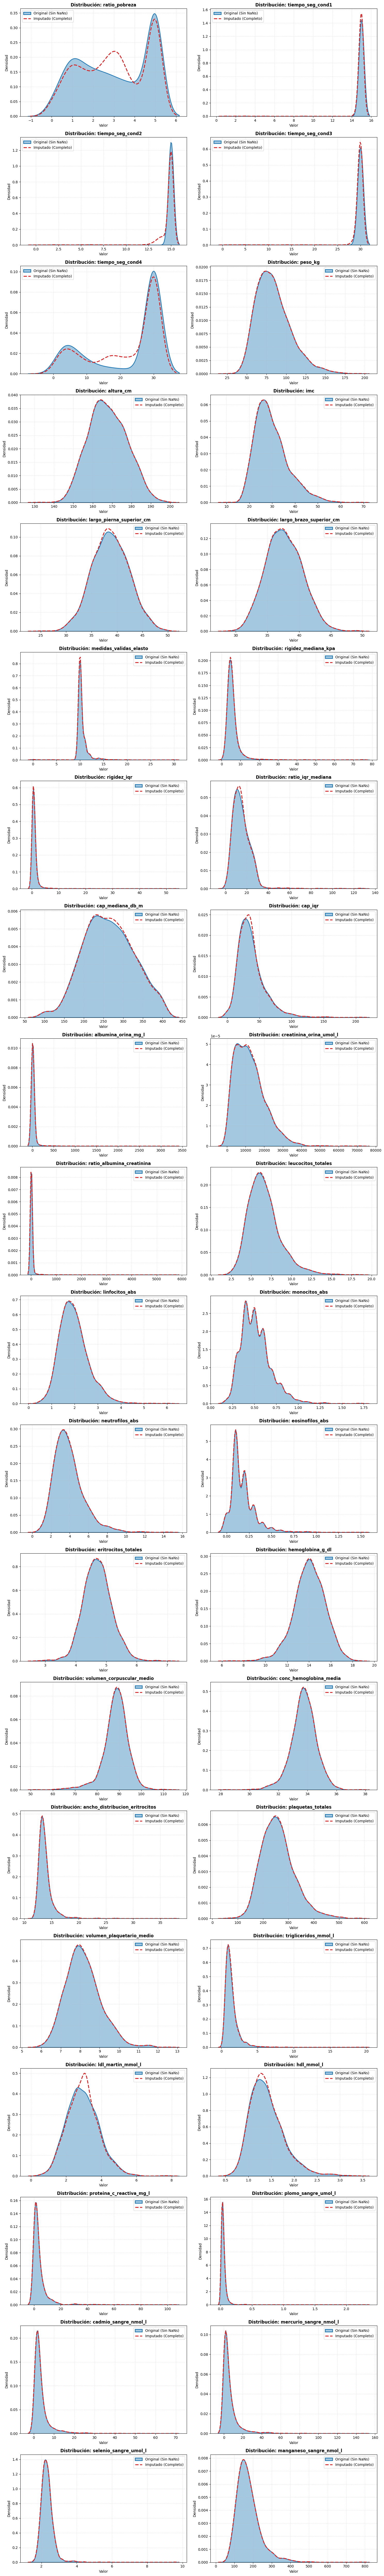

In [27]:
# =====================================================================
# 2. COMPARACIÓN VISUAL (DISTRIBUCIÓN ORIGINAL VS IMPUTADA)
# =====================================================================

def plot_comparacion_distribucion(df_orig, df_imp, columnas, n_cols=2):
    """
    Dibuja gráficos de densidad superpuestos para comparar distribuciones.
    """
    n_rows = (len(columnas) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() 
    
    for i, col in enumerate(columnas):
        ax = axes[i]
        
        # Plot de los datos originales (el dropna() es crucial para que seaborn no falle)
        sns.kdeplot(df_orig[col].dropna(), ax=ax, label='Original (Sin NaNs)', 
                    color='#1f77b4', fill=True, alpha=0.4, linewidth=2)
        
        # Plot de los datos imputados completos
        sns.kdeplot(df_imp[col], ax=ax, label='Imputado (Completo)', 
                    color='#d62728', linestyle='--', linewidth=2.5)
        
        ax.set_title(f'Distribución: {col}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Valor')
        ax.set_ylabel('Densidad')
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.6)
    
    # Ocultar gráficos vacíos si sobran cuadrículas
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
#1. Detectar cuántos nulos tiene cada columna en el Train original
nulos_por_columna = df_train.isna().sum()

# 2. Quedarnos solo con los nombres de las columnas que tenían > 0 nulos
columnas_con_nulos = nulos_por_columna[nulos_por_columna > 0].index.tolist()

# 3. Filtrar para graficar SOLO las numéricas y ordinales 
# (KDE no funciona con categorías de texto/nominales)
variables_a_revisar = [
    col for col in columnas_con_nulos 
    if col in var_numericas + var_categoricas_ordinales
]

print(f"Se encontraron {len(variables_a_revisar)} variables numéricas/ordinales que tenían nulos.")

# 4. Ejecutar la función con la lista automática
plot_comparacion_distribucion(df_train, df_train_completo, variables_a_revisar)

Checkpoint 

In [28]:
df_train_completo.head()

,edad_an,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,peso_kg,altura_cm,imc,largo_pierna_superior_cm,largo_brazo_superior_cm,medidas_validas_elasto,intentos_totales_elasto,rigidez_mediana_kpa,rigidez_iqr,ratio_iqr_mediana,cap_mediana_db_m,cap_iqr,albumina_orina_mg_l,creatinina_orina_umol_l,ratio_albumina_creatinina,peso_flebotomia,leucocitos_totales,linfocitos_abs,monocitos_abs,neutrofilos_abs,eosinofilos_abs,eritrocitos_totales,hemoglobina_g_dl,volumen_corpuscular_medio,conc_hemoglobina_media,ancho_distribucion_eritrocitos,plaquetas_totales,volumen_plaquetario_medio,trigliceridos_mmol_l,ldl_martin_mmol_l,hdl_mmol_l,proteina_c_reactiva_mg_l,plomo_sangre_umol_l,cadmio_sangre_nmol_l,mercurio_sangre_nmol_l,selenio_sangre_umol_l,manganeso_sangre_nmol_l,pulso,tamano_manguito_pa,tamano_hogar,genero,raza_etnia,periodo_examen,pais_nacimiento,psu,toma_suplementos,toma_antiacidos,estado_examen_balance,elegibilidad_balance,convulsiones,caidas,fracturas,medicacion_osteoporosis,aprueba_cond4,estado_elastografia,tipo_sonda_elasto
0,28.0,2.82,14.280183,14.34116,29.73463,25.780668,71.2,168.9,25.0,42.0,35.5,10.0,11.0,6.7,0.3,4.5,233.0,37.0,12.62,18298.8,6.10,187470.090590,8.2,2.0,0.4,5.5,0.2,2.92,9.6,92.8,35.5,20.3,232.0,7.7,0.903,0.802,1.09,0.23,0.033,1.948,0.60,2.36,176.01,59.0,3.0,3.0,0,3.0,0,1,2.0,1,0,1,1,0,0,0,0,1,1,b'M'
1,23.0,3.68,15.000000,15.00000,30.00000,30.000000,116.3,188.3,32.8,43.8,41.3,10.0,10.0,7.1,0.5,7.0,318.0,20.0,34.48,25194.0,12.10,106767.017251,8.3,2.4,0.6,5.2,0.1,5.58,16.1,83.0,34.8,13.3,252.0,9.0,2.021,3.827,1.47,1.10,0.027,0.409,0.60,2.46,120.68,81.0,5.0,2.0,1,3.0,1,1,1.0,0,0,1,1,0,0,0,0,1,1,b'M'
2,57.0,5.00,15.000000,15.00000,30.00000,30.000000,73.2,180.6,22.4,40.1,40.0,11.0,11.0,5.7,0.8,14.0,191.0,58.0,3.59,4066.4,7.80,53818.240080,4.2,1.1,0.5,2.5,0.1,4.73,15.5,92.0,35.6,13.1,257.0,8.0,0.892,3.155,1.68,0.41,0.032,2.651,1.15,2.72,213.69,76.0,3.0,1.0,1,3.0,0,1,2.0,1,0,1,0,0,0,1,0,1,1,b'M'
3,22.0,2.82,15.000000,15.00000,30.00000,30.000000,99.6,159.4,39.2,35.7,35.0,10.0,10.0,6.6,0.8,12.1,292.0,58.0,35.70,37658.4,8.38,28277.994331,8.0,2.3,0.4,5.0,0.2,4.77,12.8,79.0,33.8,15.1,396.0,7.5,1.389,2.534,1.42,6.03,0.015,1.904,0.90,2.02,111.40,97.0,4.0,3.0,0,1.0,1,1,1.0,0,1,1,1,0,0,0,0,1,1,b'XL'
4,44.0,1.41,15.000000,15.00000,30.00000,2.000000,69.4,152.9,29.7,38.5,35.5,10.0,10.0,7.6,1.4,18.4,255.0,90.0,12.43,13878.8,7.92,85328.844519,5.7,1.7,0.3,3.3,0.3,4.86,13.8,82.5,34.4,13.3,235.0,9.1,4.234,2.327,1.27,5.62,0.019,2.402,2.74,2.04,217.15,81.0,4.0,7.0,0,2.0,1,0,1.0,1,0,1,0,0,1,1,0,0,1,b'M'


In [29]:
df_test_completo.head()

,edad_an,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,peso_kg,altura_cm,imc,largo_pierna_superior_cm,largo_brazo_superior_cm,medidas_validas_elasto,intentos_totales_elasto,rigidez_mediana_kpa,rigidez_iqr,ratio_iqr_mediana,cap_mediana_db_m,cap_iqr,albumina_orina_mg_l,creatinina_orina_umol_l,ratio_albumina_creatinina,peso_flebotomia,leucocitos_totales,linfocitos_abs,monocitos_abs,neutrofilos_abs,eosinofilos_abs,eritrocitos_totales,hemoglobina_g_dl,volumen_corpuscular_medio,conc_hemoglobina_media,ancho_distribucion_eritrocitos,plaquetas_totales,volumen_plaquetario_medio,trigliceridos_mmol_l,ldl_martin_mmol_l,hdl_mmol_l,proteina_c_reactiva_mg_l,plomo_sangre_umol_l,cadmio_sangre_nmol_l,mercurio_sangre_nmol_l,selenio_sangre_umol_l,manganeso_sangre_nmol_l,pulso,tamano_manguito_pa,tamano_hogar,genero,raza_etnia,periodo_examen,pais_nacimiento,psu,toma_suplementos,toma_antiacidos,estado_examen_balance,elegibilidad_balance,convulsiones,caidas,fracturas,medicacion_osteoporosis,aprueba_cond4,estado_elastografia,tipo_sonda_elasto
0,31.0,5.00000,15.0,15.0,30.0,30.0,70.5,153.7,29.8,34.3,33.5,10.0,10.0,4.1,0.2,4.9,261.0,17.0,6.86,11580.4,5.24,62341.147207,5.1,1.4,0.4,3.3,5.397605e-79,4.22,13.1,90.4,34.3,12.3,310.0,8.0,1.152,2.276,1.55,1.33,0.019,3.007,0.60,2.27,202.59,69.0,4.0,2.0,0,2.0,0,1,1.0,1,0,1,1,0,0,0,0,1,1,b'M'
1,26.0,5.00000,15.0,15.0,30.0,30.0,96.0,180.2,29.6,43.5,43.4,10.0,11.0,5.3,0.3,5.7,320.0,37.0,49.96,4950.4,89.21,227206.368527,5.7,1.7,0.5,3.2,3.000000e-01,5.05,15.3,85.9,35.3,13.2,266.0,7.7,1.806,3.233,1.11,7.64,0.016,0.409,1.05,2.16,102.11,92.0,4.0,2.0,1,3.0,0,1,2.0,1,0,1,1,0,0,0,0,1,1,b'M'
2,58.0,5.00000,15.0,15.0,30.0,30.0,79.5,156.6,32.4,34.5,33.9,10.0,30.0,4.7,1.0,21.3,290.0,49.0,4.08,6188.0,5.83,40013.265871,6.9,1.4,0.5,4.9,1.000000e-01,4.97,15.2,91.2,33.6,14.2,291.0,9.1,0.982,3.077,1.47,1.60,0.041,1.788,7.24,2.30,100.29,60.0,4.0,2.0,0,3.0,0,1,2.0,1,0,1,1,0,0,0,0,1,1,b'M'
3,59.0,3.55484,15.0,15.0,30.0,30.0,81.0,163.8,30.2,38.4,37.2,11.0,14.0,4.2,0.2,4.8,259.0,32.0,6.75,8840.0,6.75,34557.727087,5.2,2.2,0.4,2.3,2.000000e-01,4.10,12.6,90.3,34.0,13.0,249.0,7.1,0.644,4.474,2.07,0.75,0.103,2.669,20.36,1.88,165.82,70.0,4.0,1.0,0,3.0,1,1,1.0,1,0,1,0,0,0,1,0,1,1,b'M'
4,68.0,1.16000,15.0,15.0,30.0,2.0,74.9,151.8,32.5,33.3,33.9,10.0,14.0,7.0,1.9,27.1,275.0,37.0,10.39,12287.6,7.47,9950.211756,7.8,1.6,0.7,5.2,2.000000e-01,5.11,16.0,93.1,33.7,14.9,345.0,7.5,1.129,1.888,3.05,8.86,0.031,2.856,6.34,3.16,204.41,80.0,4.0,1.0,0,3.0,1,1,2.0,1,0,1,0,0,0,0,0,0,1,b'M'


In [30]:
 df_train_completo.to_csv('train_imputado.csv', index=False, encoding='utf-8')
 df_test_completo.to_csv('test_imputado.csv', index=False, encoding='utf-8')

### A partir de aquí ya vendría:

- Reagrupación de categorías poco frecuentes **NO**
- One-Hot para categóricas nominales
- Transformación de variables **AUN NO**
- Creación de variables derivadas **AUN NO**
- Normalización/estandarización de variables numéricas

In [39]:
df_train_final = df_train_completo.copy()
df_test_final = df_test_completo.copy()

#### Reagrupación

#### One-hot encoding

In [40]:
print(f" -  dimensiones de Train: {df_train_final.shape}")
print(f" -  dimensiones de Test:  {df_test_final.shape}")

 -  dimensiones de Train: (1925, 65)
 -  dimensiones de Test:  (516, 65)


In [41]:
# 1. Inicializar el codificador
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

In [42]:
# 2. Ajustar (FIT) solo con el conjunto de Train y transformar ambos

train_encoded_array = encoder.fit_transform(df_train_final[var_categoricas_nominales])
test_encoded_array = encoder.transform(df_test_final[var_categoricas_nominales])

In [43]:
# 3. Obtener los nombres de las nuevas columnas generadas automáticamente
nuevas_columnas = encoder.get_feature_names_out(var_categoricas_nominales)

In [44]:
print (nuevas_columnas)

['genero_2.0' 'raza_etnia_2.0' 'raza_etnia_3.0' 'raza_etnia_4.0'
 'raza_etnia_6.0' 'raza_etnia_7.0' 'periodo_examen_2.0'
 'pais_nacimiento_2.0' 'estrato_174.0' 'estrato_175.0' 'estrato_176.0'
 'estrato_177.0' 'estrato_178.0' 'estrato_179.0' 'estrato_180.0'
 'estrato_181.0' 'estrato_182.0' 'estrato_183.0' 'estrato_184.0'
 'estrato_185.0' 'estrato_186.0' 'estrato_187.0' 'psu_2.0'
 'toma_suplementos_2.0' 'toma_suplementos_7.0' 'toma_suplementos_9.0'
 'toma_antiacidos_2.0' 'toma_antiacidos_7.0' 'estado_examen_balance_2.0'
 'estado_examen_balance_3.0' 'estado_examen_balance_4.0'
 'elegibilidad_balance_2.0' 'convulsiones_2.0' 'convulsiones_9.0'
 'caidas_2.0' 'caidas_9.0' 'fracturas_2.0' 'medicacion_osteoporosis_2.0'
 'aprueba_cond4_2.0' 'aprueba_cond4_7.0' 'estado_elastografia_2.0'
 'estado_elastografia_3.0' 'estado_elastografia_4.0'
 "tipo_sonda_elasto_b'M'" "tipo_sonda_elasto_b'XL'"]


In [45]:
# 4. Convertir los arrays resultantes en DataFrames limpios (manteniendo los índices originales)
df_train_encoded = pd.DataFrame(train_encoded_array, columns=nuevas_columnas, index=df_train_final.index)
df_test_encoded = pd.DataFrame(test_encoded_array, columns=nuevas_columnas, index=df_test_final.index)

In [46]:
#5. Unir las nuevas columnas codificadas y eliminar las nominales de texto originales
# Primero eliminamos las originales
df_train_sin_nominales = df_train_final.drop(columns=var_categoricas_nominales)
df_test_sin_nominales = df_test_final.drop(columns=var_categoricas_nominales)

In [47]:
df_train_final = pd.concat([df_train_sin_nominales, df_train_encoded], axis=1)
df_test_final = pd.concat([df_test_sin_nominales, df_test_encoded], axis=1)

print(f" - Nuevas dimensiones de Train: {df_train_final.shape}")
print(f" - Nuevas dimensiones de Test:  {df_test_final.shape}")



 - Nuevas dimensiones de Train: (1925, 93)
 - Nuevas dimensiones de Test:  (516, 93)


In [48]:
# Verificamos que ambos datasets tengan exactamente las mismas columnas y en el mismo orden
columnas_identicas = list(df_train_final.columns) == list(df_test_final.columns)
print(f" - ¿Tienen Train y Test las mismas columnas exactas?: {columnas_identicas}")

 - ¿Tienen Train y Test las mismas columnas exactas?: True


#### Transformación variables

#### Variables Derivadas

#### Normalización y estandarización

- Hacer transform al test y fit al train!!

In [49]:
# 1. Inicializar el escalador
scaler = StandardScaler()

In [50]:
df_train_final[var_numericas] = scaler.fit_transform(df_train_final[var_numericas])

df_test_final[var_numericas] = scaler.transform(df_test_final[var_numericas])

In [51]:
media_train = df_train_final[var_numericas[0]].mean()
std_train = df_train_final[var_numericas[0]].std()

In [52]:
print(f" - Ejemplo variable '{var_numericas[0]}' en Train -> Media: {media_train:.4f}, Desviación Estándar: {std_train:.4f}")

 - Ejemplo variable 'edad_an' en Train -> Media: -0.0000, Desviación Estándar: 1.0003


In [53]:
# La media del Test NO será exactamente 0, y eso es perfecto, 
# demuestra que se estandarizó basándose en el Train y no en sí mismo.
media_test = df_test_final[var_numericas[0]].mean()
print(f" - Ejemplo variable '{var_numericas[0]}' en Test  -> Media: {media_test:.4f} ")

 - Ejemplo variable 'edad_an' en Test  -> Media: -0.0526 


In [54]:
df_train_final.head()

,edad_an,ratio_pobreza,peso_dieta_dia1,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,peso_kg,altura_cm,imc,largo_pierna_superior_cm,largo_brazo_superior_cm,medidas_validas_elasto,intentos_totales_elasto,rigidez_mediana_kpa,rigidez_iqr,ratio_iqr_mediana,cap_mediana_db_m,cap_iqr,albumina_orina_mg_l,creatinina_orina_umol_l,ratio_albumina_creatinina,peso_flebotomia,leucocitos_totales,linfocitos_abs,monocitos_abs,neutrofilos_abs,eosinofilos_abs,eritrocitos_totales,hemoglobina_g_dl,volumen_corpuscular_medio,conc_hemoglobina_media,ancho_distribucion_eritrocitos,plaquetas_totales,volumen_plaquetario_medio,peso_muestra_ayuno,trigliceridos_mmol_l,ldl_martin_mmol_l,hdl_mmol_l,proteina_c_reactiva_mg_l,plomo_sangre_umol_l,cadmio_sangre_nmol_l,mercurio_sangre_nmol_l,selenio_sangre_umol_l,manganeso_sangre_nmol_l,pulso,tamano_manguito_pa,tamano_hogar,genero_2.0,raza_etnia_2.0,raza_etnia_3.0,raza_etnia_4.0,raza_etnia_6.0,raza_etnia_7.0,periodo_examen_2.0,pais_nacimiento_2.0,estrato_174.0,estrato_175.0,estrato_176.0,estrato_177.0,estrato_178.0,estrato_179.0,estrato_180.0,estrato_181.0,estrato_182.0,estrato_183.0,estrato_184.0,estrato_185.0,estrato_186.0,estrato_187.0,psu_2.0,toma_suplementos_2.0,toma_suplementos_7.0,toma_suplementos_9.0,toma_antiacidos_2.0,toma_antiacidos_7.0,estado_examen_balance_2.0,estado_examen_balance_3.0,estado_examen_balance_4.0,elegibilidad_balance_2.0,convulsiones_2.0,convulsiones_9.0,caidas_2.0,caidas_9.0,fracturas_2.0,medicacion_osteoporosis_2.0,aprueba_cond4_2.0,aprueba_cond4_7.0,estado_elastografia_2.0,estado_elastografia_3.0,estado_elastografia_4.0,tipo_sonda_elasto_b'M',tipo_sonda_elasto_b'XL'
0,0.712090,0.668306,0.431206,0.132444,0.221993,0.164847,0.790793,0.492201,-1.038181,1.164731,-1.140350,-0.915092,0.355368,-0.491350,-0.244246,-0.123563,0.104963,0.455454,3.190076,-0.148034,-0.556400,-0.096071,0.959022,0.900184,1.263536,1.090882,0.446831,0.005101,1.495392,-0.308872,-2.110565,-1.175898,1.126527,0.370053,-0.276029,0.837437,-0.675560,0.130140,0.713215,0.817360,2.265828,-0.101834,0.222296,0.409612,1.059133,0.228879,4.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-1.100179,0.130163,5.968457,0.132444,0.221993,0.164847,0.790793,1.364957,1.104241,0.832955,0.375378,0.825413,-0.289172,-0.491350,0.046700,-0.288529,-0.496971,1.439218,-1.004648,-0.145012,0.308085,-0.118459,3.582108,0.046883,0.504005,-0.074577,-0.124947,-0.673260,1.243105,1.003214,-0.221594,-0.248771,0.217513,-0.447708,0.169024,3.159045,0.542071,-0.247341,-1.488153,0.686842,-0.418496,-0.464027,-0.127794,-0.098025,0.344029,-0.023417,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.712090,-0.324815,-0.679488,-0.120447,-0.572437,-0.051298,-0.270849,-0.470996,-0.222020,-0.411208,0.235033,0.651362,-0.289172,1.239941,-0.226062,-0.343517,-0.470512,0.852133,-0.708550,-0.034157,-0.135241,-0.041669,-0.653075,0.297854,1.111630,-0.074577,0.002115,-0.673260,1.327200,1.417557,-0.134943,0.678357,-0.062184,-1.326043,1.949235,-0.599826,1.277989,-0.537192,-1.010748,-0.201518,0.198755,-0.492085,-0.536382,-0.071307,1.976013,1.238061,3.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.403153,1.232075,-0.461236,-0.168342,-0.260580,0.037785,0.141136,1.835251,0.318686,1.786813,0.228058,0.384424,0.208298,0.254784,0.011216,-0.089754,-0.010628,1.043628,-0.053362,0.355557,-1.121641,0.981354,-0.399651,2.757369,2.478785,2.256340,2.162166,0.683461,1.621536,1.555672,0.194327,-0.596444,-0.901274,0.067178,-0.943608,-0.326513,0.396810,-0.798956,-0.108983,0.598427,-0.002210,0.356983,-0.339288,-0.098025,-0.362811,1.322159,5.0,1.0,0.0,0.0,1.0,0.0,0.0,0.

In [55]:
df_test_final.head()

,edad_an,ratio_pobreza,peso_dieta_dia1,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,peso_kg,altura_cm,imc,largo_pierna_superior_cm,largo_brazo_superior_cm,medidas_validas_elasto,intentos_totales_elasto,rigidez_mediana_kpa,rigidez_iqr,ratio_iqr_mediana,cap_mediana_db_m,cap_iqr,albumina_orina_mg_l,creatinina_orina_umol_l,ratio_albumina_creatinina,peso_flebotomia,leucocitos_totales,linfocitos_abs,monocitos_abs,neutrofilos_abs,eosinofilos_abs,eritrocitos_totales,hemoglobina_g_dl,volumen_corpuscular_medio,conc_hemoglobina_media,ancho_distribucion_eritrocitos,plaquetas_totales,volumen_plaquetario_medio,peso_muestra_ayuno,trigliceridos_mmol_l,ldl_martin_mmol_l,hdl_mmol_l,proteina_c_reactiva_mg_l,plomo_sangre_umol_l,cadmio_sangre_nmol_l,mercurio_sangre_nmol_l,selenio_sangre_umol_l,manganeso_sangre_nmol_l,pulso,tamano_manguito_pa,tamano_hogar,genero_2.0,raza_etnia_2.0,raza_etnia_3.0,raza_etnia_4.0,raza_etnia_6.0,raza_etnia_7.0,periodo_examen_2.0,pais_nacimiento_2.0,estrato_174.0,estrato_175.0,estrato_176.0,estrato_177.0,estrato_178.0,estrato_179.0,estrato_180.0,estrato_181.0,estrato_182.0,estrato_183.0,estrato_184.0,estrato_185.0,estrato_186.0,estrato_187.0,psu_2.0,toma_suplementos_2.0,toma_suplementos_7.0,toma_suplementos_9.0,toma_antiacidos_2.0,toma_antiacidos_7.0,estado_examen_balance_2.0,estado_examen_balance_3.0,estado_examen_balance_4.0,elegibilidad_balance_2.0,convulsiones_2.0,convulsiones_9.0,caidas_2.0,caidas_9.0,fracturas_2.0,medicacion_osteoporosis_2.0,aprueba_cond4_2.0,aprueba_cond4_7.0,estado_elastografia_2.0,estado_elastografia_3.0,estado_elastografia_4.0,tipo_sonda_elasto_b'M',tipo_sonda_elasto_b'XL'
0,-0.333450,1.232075,1.268795,0.132444,0.221993,0.164847,-0.541860,1.839773,2.257067,0.667066,1.049035,1.521615,2.288987,0.278113,0.010331,-0.343517,-0.582961,1.693093,0.574542,-0.038656,-0.545317,-0.002559,1.714455,-1.107584,-1.166963,-1.240035,-0.760256,-0.673260,1.032865,1.831900,0.280977,2.184940,-0.411805,-1.462337,0.280287,1.405021,18.545908,0.070679,-2.098171,0.147932,0.126982,-0.657473,-0.339288,0.623354,-1.322104,0.144780,4.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.194045,1.232075,-0.406041,0.132444,0.221993,0.164847,0.790793,0.153047,0.492120,-0.065607,0.459585,0.686172,1.644447,0.085747,-0.644296,-0.178551,0.832574,-2.495840,0.475843,-0.064313,0.130755,-0.073848,-0.332201,-0.455059,0.655911,-0.074577,-0.696725,-0.673260,0.044739,0.381700,0.471607,-0.016989,-0.132108,0.082322,0.725340,-0.192747,-0.326292,1.322123,0.156242,-0.313791,0.040854,-0.423520,2.611726,0.436330,-1.106451,-0.528008,4.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-1.797206,1.232075,0.625151,0.132444,0.221993,0.164847,0.790793,-0.262982,-0.222020,-0.176200,0.515723,-0.288510,-0.289172,-0.298984,-0.407903,-0.343517,-0.324990,-0.195100,-0.659200,-0.128703,0.385667,-0.112298,1.008684,-0.304477,-0.407432,-0.074577,-0.124947,-0.673260,-0.312668,-0.377929,-0.065623,-0.248771,0.007740,-0.311415,1.170393,0.778633,-0.446987,0.305398,-0.188550,-0.131347,-0.475915,-0.370959,-0.536382,0.890532,0.735574,-0.023417,4.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.712090,-1.477860,-1.138289,0.132444,0.221993,0.164847,0.790793,1.188597,1.328685,0.556474,2.340211,1.382374,0.355368,0.278113,-0.244246,-0.343517,-0.457283,1.106008,-1.103348,-0.158578,-0.301488,-0.113783,-0.941506,-1.157778,-1.015057,-0.074577,-1.077910,0.005101,0.023715,-0.170757,-0.100283,-0.712335,1.965617,1.187813,-1.388661,-0.891071,-0.506800,0.362694,0.315378,-0.390979,0.026499,-0.418382,-0.208792,0.169153,0.037466,-0.191614,4.0,1.0,0.0,0.0,0.0,

In [56]:
 df_train_final.to_csv('data/testset.csv', index=False, encoding='utf-8')
 df_test_final.to_csv('data/trainset.csv', index=False, encoding='utf-8')